**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载地址（4月17日前有效）：https://f.ws59.cn/f/du8yd2536vl
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或log-mel频谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。
  - 原数完整据集下载地址：https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing \
    或国内访问地址（4月17日前有效）：https://f.ws59.cn/f/du8xu130kba

## 1. 实验准备

In [1]:
# 1. 导入必要的库
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore')

## 2. 数据预处理

In [2]:
# 2. 数据预处理
def load_json_data(json_file):
    """加载JSON格式的数据集"""
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

# 加载训练集和测试集
train_data = load_json_data('trainset.json')
test_data = load_json_data('testset.json')

- 数据集信息展示

In [3]:
# 打印数据集信息
print(f"训练集样本数: {len(train_data)}")
print(f"测试集样本数: {len(test_data)}")

# 查看数据样例
print("\n训练集样例:")
print(train_data[0])

# 统计说话人和方言区域的分布
train_speakers = set([item['speaker_id'] for item in train_data])
test_speakers = set([item['speaker_id'] for item in test_data])
train_dialects = set([item['dialect_region'] for item in train_data])

print(f"\n训练集包含 {len(train_speakers)} 位说话人")
print(f"测试集包含 {len(test_speakers)} 位说话人")
print(f"数据集包含 {len(train_dialects)} 个方言区域")

# 创建说话人ID到索引的映射
all_speakers = sorted(list(train_speakers.union(test_speakers)))
speaker_to_idx = {speaker: idx for idx, speaker in enumerate(all_speakers)}
idx_to_speaker = {idx: speaker for speaker, idx in speaker_to_idx.items()}

print(f"\n共有 {len(speaker_to_idx)} 位说话人")


训练集样本数: 2772
测试集样本数: 924

训练集样例:
{'audio_filepath': './Dataset/TRAIN/DR1/FCJF0/SI648_.wav', 'dialect_region': 'DR1', 'gender': 'F', 'speaker_id': 'CJF0'}

训练集包含 462 位说话人
测试集包含 462 位说话人
数据集包含 8 个方言区域

共有 462 位说话人


- 数据集信息可视化

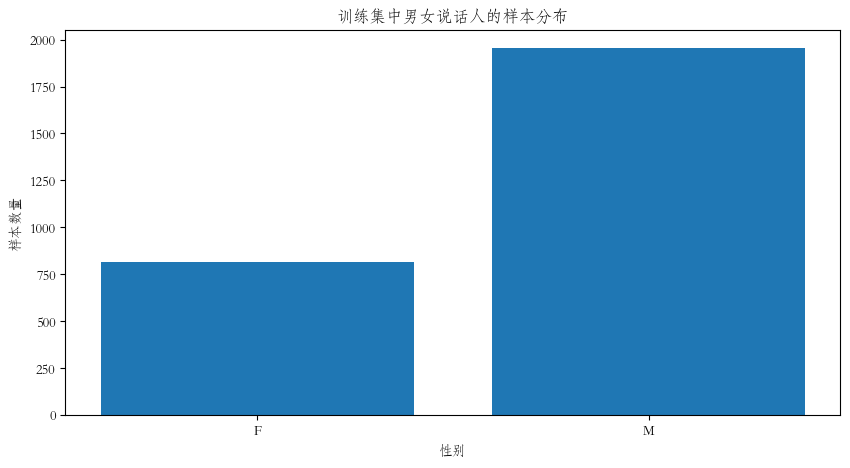


显示样本音频: ./Dataset/TRAIN/DR1/FCJF0/SI648_.wav


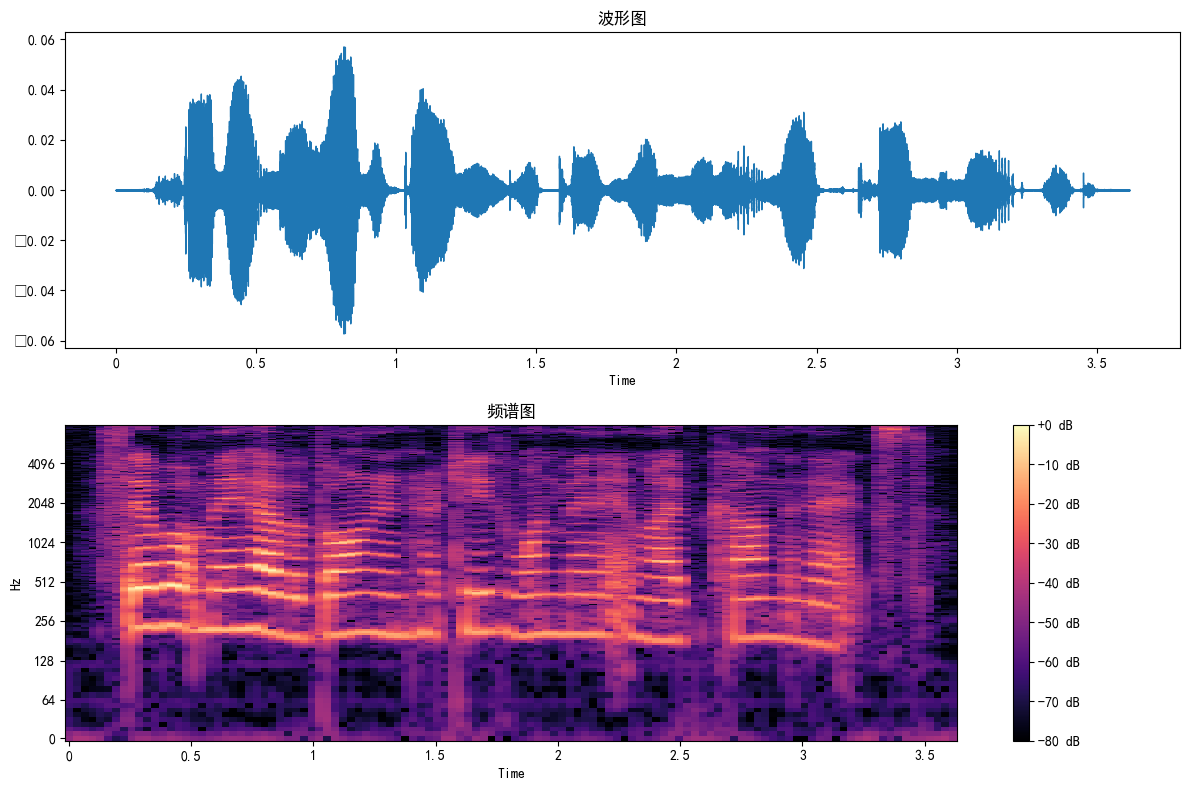

In [14]:
# 可视化数据集中的音频样本分布
train_gender_counts = {"F": 0, "M": 0}
for item in train_data:
    train_gender_counts[item['gender']] += 1

plt.figure(figsize=(10, 5))
plt.bar(train_gender_counts.keys(), train_gender_counts.values())
plt.title('训练集中男女说话人的样本分布')
plt.xlabel('性别')
plt.ylabel('样本数量')
plt.show()

# 可视化一个音频样本的波形
def plot_audio_sample(audio_path):
    """绘制音频波形和频谱图"""
    y, sr = librosa.load(audio_path, sr=None)
    
    plt.rcParams['font.family'] = 'SimHei'
    plt.figure(figsize=(12, 8))
    
    # 波形图
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(y, sr=sr)
    plt.title('波形图')
    
    # 频谱图
    plt.subplot(2, 1, 2)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title('频谱图')
    
    plt.tight_layout()
    plt.show()

# 展示一个样本的波形和频谱，以确认加载成功
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    print(f"\n显示样本音频: {sample_path}")
    plot_audio_sample(sample_path)

## 3. 特征提取 ——log-mel频谱图特征



In [5]:
# 3. 特征提取 - log-mel频谱图特征
def extract_spectrogram_features(audio_path, n_fft=512, hop_length=256):
    """
    从音频文件中提取log-mel频谱图特征
    
    参数:
    audio_path: 音频文件路径
    n_fft: FFT窗口大小
    hop_length: 帧移
    
    返回:
    spectrogram_features: log-mel频谱图特征向量
    """
    # 加载音频文件
    y, sr = librosa.load(audio_path, sr=None)
    
    # 计算短时傅里叶变换 (STFT)
    D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
    
    # 计算幅度谱
    spectrogram = np.abs(D)
    
    # 转换为log-mel频谱
    mel_spectrogram = librosa.feature.melspectrogram(S=spectrogram, sr=sr, n_mels=128)
    log_mel_spectrogram = librosa.power_to_db(mel_spectrogram)
    
    # 压缩和归一化特征
    # 使用平均池化来压缩时间维度
    n_frames = log_mel_spectrogram.shape[1]
    frame_segments = 64  # 将log-mel频谱图分为64个时间段
    segment_size = n_frames // frame_segments if n_frames >= frame_segments else 1
    
    compressed_spec = np.zeros((log_mel_spectrogram.shape[0], frame_segments))
    
    for i in range(frame_segments):
        start = i * segment_size
        end = min((i + 1) * segment_size, n_frames)
        if start < end:
            compressed_spec[:, i] = np.mean(log_mel_spectrogram[:, start:end], axis=1)
    
    # 展平特征向量
    flattened_features = compressed_spec.flatten()
    
    return flattened_features

# 可视化log-mel频谱图特征
def visualize_spectrogram(audio_path, title="log-mel频谱图"):
    """可视化音频的log-mel频谱图"""
    y, sr = librosa.load(audio_path, sr=None)
    
    plt.rcParams['font.family'] = 'STFangsong'
    plt.figure(figsize=(12, 6))
    
    # 计算短时傅里叶变换 (STFT)
    D = librosa.stft(y)
    
    # 计算幅度谱
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    
    # 绘制log-mel频谱图
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# 为训练集和测试集提取log-mel频谱图特征
def prepare_spectrogram_data(data_list):
    """
    从数据集中提取log-mel频谱图特征和标签
    
    返回:
    X: 特征矩阵
    y: 标签向量
    """
    features = []
    speaker_ids = []
    
    for item in data_list:
        # 提取特征
        feature = extract_spectrogram_features(item['audio_filepath'])
        features.append(feature)
        
        # 获取标签
        speaker_ids.append(speaker_to_idx[item['speaker_id']])
    
    return np.array(features), np.array(speaker_ids)

- 说明线性声谱图（Spectrogram）、Mel频谱图（Mel Spectrogram）、Log-Mel频谱图、MFCC的关系：<br>
        原始音频波形<br>
               ↓<br>
     ┌────────────────────┐<br>
     │    STFT（傅里叶变换）│<br>
     └────────────────────┘<br>
               ↓<br>
       线性声谱图（Spectrogram）<br>
               ↓<br>
     ┌────────────────────┐<br>
     │ 应用 Mel 滤波器组     │<br>
     └────────────────────┘<br>
               ↓<br>
      Mel 频谱图（Mel Spectrogram）<br>
               ↓<br>
     ┌────────────────────┐<br>
     │     对数变换 log     │<br>
     └────────────────────┘<br>
               ↓<br>
     Log-Mel 频谱图（当前提取的特征）<br>
               ↓<br>
     ┌────────────────────┐<br>
     │ 离散余弦变换（DCT） │<br>
     └────────────────────┘<br>
               ↓<br>
             MFCC<br>




Log-Mel频谱图没有进行 DCT 变换，所以还不是 MFCC。通常比 MFCC 保留更多细节，但维度更高

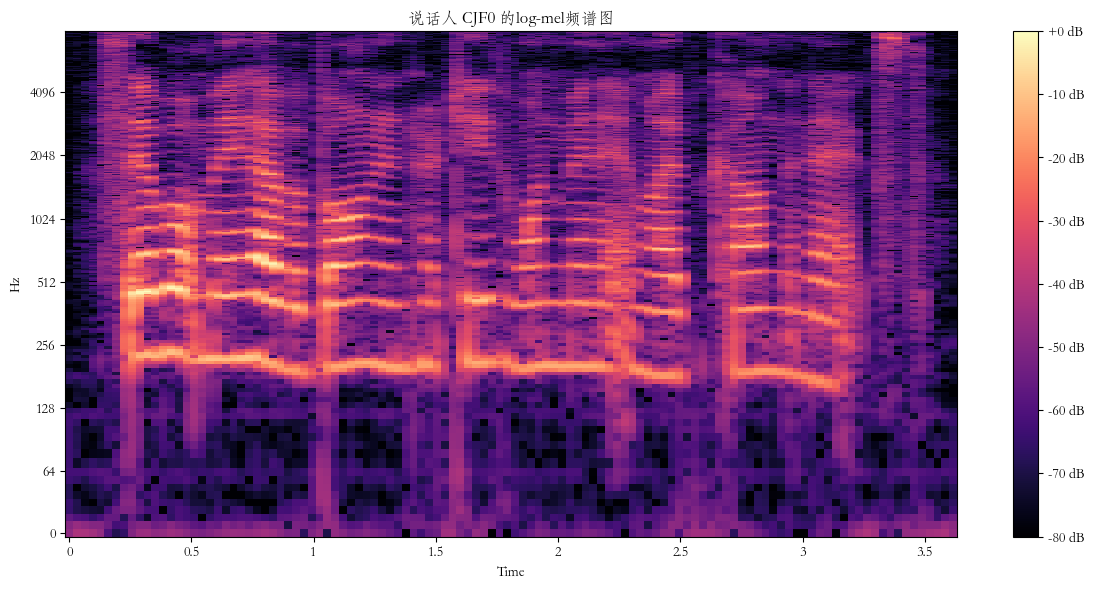

正在为训练集提取log-mel频谱图特征...
正在为测试集提取log-mel频谱图特征...
log-mel频谱图特征提取完成!
训练集特征形状: (2772, 8192), 标签形状: (2772,)
测试集特征形状: (924, 8192), 标签形状: (924,)


In [6]:
# 使用训练集样本可视化log-mel频谱图
if len(train_data) > 0:
    sample_path = train_data[0]['audio_filepath']
    sample_speaker = train_data[0]['speaker_id']
    
    # 可视化log-mel频谱图
    visualize_spectrogram(sample_path, f"说话人 {sample_speaker} 的log-mel频谱图")

print("正在为训练集提取log-mel频谱图特征...")
X_train, y_train = prepare_spectrogram_data(train_data)

print("正在为测试集提取log-mel频谱图特征...")
X_test, y_test = prepare_spectrogram_data(test_data)

print("log-mel频谱图特征提取完成!")
print(f"训练集特征形状: {X_train.shape}, 标签形状: {y_train.shape}")
print(f"测试集特征形状: {X_test.shape}, 标签形状: {y_test.shape}")

- log-mel频谱图图像解读：<br>
横轴是时间，纵轴是频率，颜色表示“声音强度”（能量）。
1. 每一个横向的“亮条纹”
<br>表示在那个时间点，某些频率特别“响”
<br>比如你图中亮亮的水平线，是某些频率一直在“持续发声”

2. 亮带上下位置
<br>靠上是高频、靠下是低频
<br>低频多说明声音低沉，高频多说明声音尖锐。

3. 像阶梯的条纹（清晰的横线）
<br>是元音（如 "a", "o"）的“共振峰”
<br>这些是发音时喉咙/口腔共鸣形成的频率，非常重要！

4. 突变/断层/模糊区域
<br>可能是辅音、停顿、快速变化的部分
<br>比如发 "s", "t", "k" 的时候，能量分布比较分散

5. 竖向亮条
<br>瞬间爆发的声音，例如“啪”、“卡”这样的爆破音

## 4. 模型选择和训练 - Softmax分类器

In [7]:
# 4. 模型选择和训练 - Softmax分类器
def train_softmax_classifier(X_train, y_train):
    """
    训练Softmax分类器 (多类别逻辑回归)
    
    参数:
    X_train: 训练特征
    y_train: 训练标签
    
    返回:
    model: 训练好的模型
    """
    # 创建处理管道: 标准化特征 + Softmax分类器
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            multi_class='multinomial',  # 多类别分类
            solver='lbfgs',             # 优化算法
            C=1.0,                      # 正则化强度的倒数
            max_iter=1000,              # 最大迭代次数
            random_state=42
        ))
    ])
    
    # 训练模型
    print("训练Softmax分类器...")
    pipeline.fit(X_train, y_train)
    
    return pipeline

In [8]:
print("开始Softmax分类器训练...")
# 训练Softmax分类器
softmax_model = train_softmax_classifier(X_train, y_train)
print("Softmax分类器训练完成!")

开始Softmax分类器训练...
训练Softmax分类器...
Softmax分类器训练完成!


## 5. 评价指标(准确率Accuracy)

In [9]:
# 5. 评估和分析
def evaluate_softmax_model(model, X_test, y_test):
    """
    评估Softmax模型在测试集上的性能
    
    返回:
    y_true: 真实标签
    y_pred: 预测标签
    accuracy: 准确率
    """
    # 预测测试集
    y_pred = model.predict(X_test)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    
    return y_test, y_pred, accuracy

# 评估模型性能
print("评估Softmax模型性能...")
y_true, y_pred, accuracy = evaluate_softmax_model(softmax_model, X_test, y_test)
print(f"Softmax模型准确率: {accuracy:.4f}")


评估Softmax模型性能...
Softmax模型准确率: 0.0779


- log-mel频谱图+Softmax的低准确率相比MFCC+GMM不足为奇，因为GMM更适合建模语音数据的概率分布，而简单的线性分类器如Softmax往往难以处理高维log-mel频谱图特征。(为什么GMM更适合？Softmax弱在哪里？)

##  6. 分析和可视化

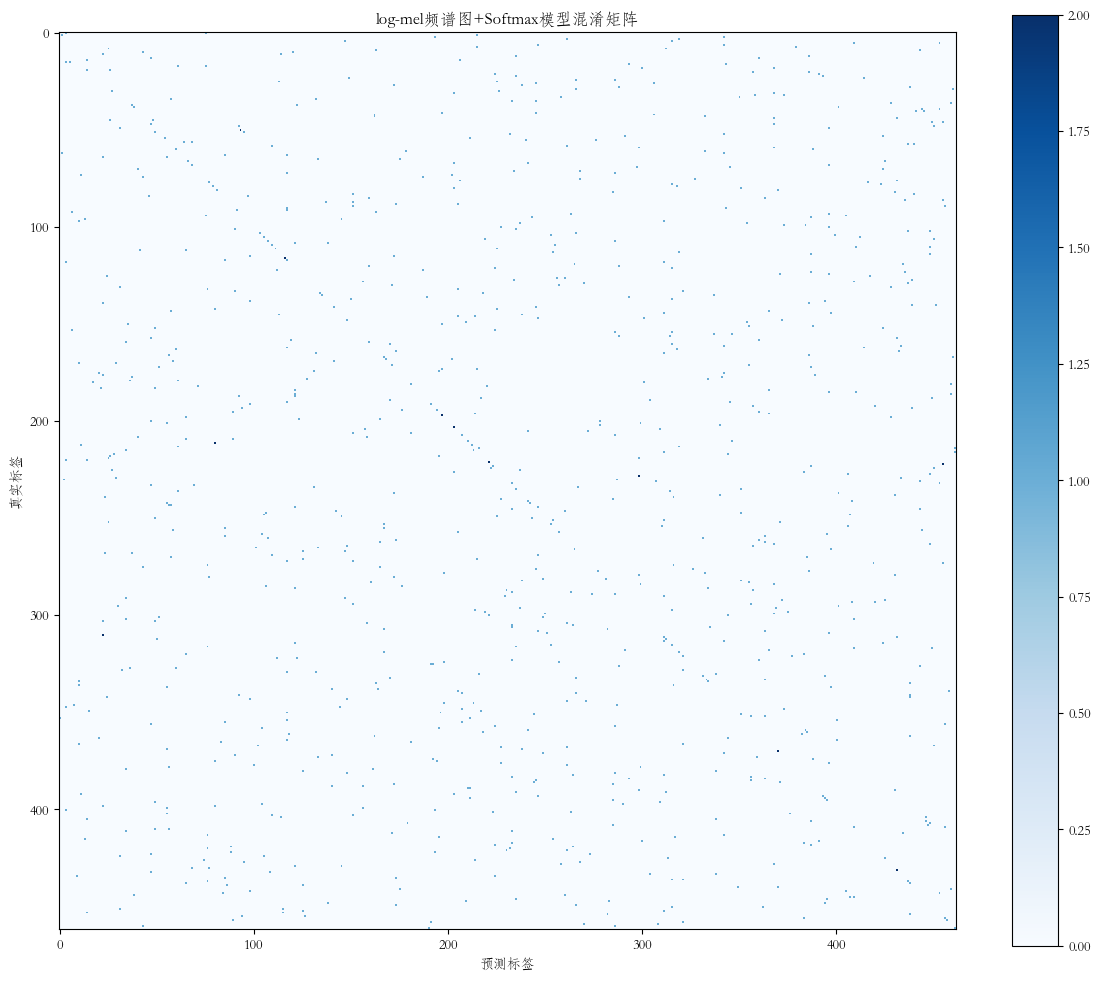

In [10]:
# 1. 混淆矩阵可视化
def plot_confusion_matrix(y_true, y_pred):
    """绘制混淆矩阵"""
    # 获取唯一的标签
    unique_labels = sorted(set(y_true).union(set(y_pred)))
    
    # 获取标签名称
    label_names = [idx_to_speaker[idx] for idx in unique_labels]
    
    # 如果说话人数量很多，使用更紧凑的可视化
    if len(unique_labels) > 40:
        # 计算混淆矩阵
        cm = confusion_matrix(y_true, y_pred)
        
        # 绘制混淆矩阵
        plt.figure(figsize=(12, 10))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('log-mel频谱图+Softmax模型混淆矩阵')
        plt.colorbar()
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.tight_layout()
        plt.show()
    else:
        # 对于中等数量的说话人，使用seaborn的热图
        cm = confusion_matrix(y_true, y_pred, labels=unique_labels)
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, xticklabels=label_names, yticklabels=label_names,
                    annot=(len(unique_labels) <= 15), fmt='d', cmap='Blues')
        plt.xlabel('预测标签')
        plt.ylabel('真实标签')
        plt.title('log-mel频谱图+Softmax模型混淆矩阵')
        plt.tight_layout()
        plt.show()

plot_confusion_matrix(y_true, y_pred)

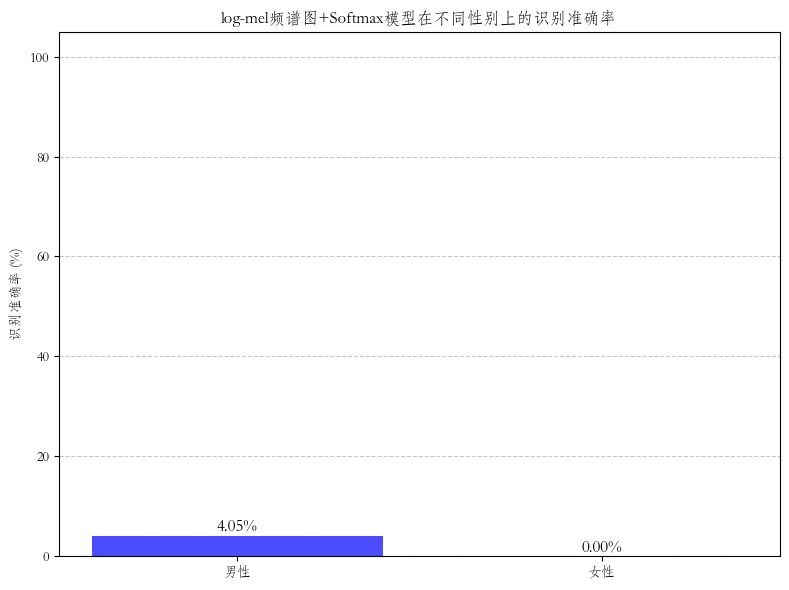

<Figure size 1000x800 with 0 Axes>

In [11]:
# 3. 分析性别因素对准确率的影响
def analyze_gender_impact():
    """分析说话人性别对模型性能的影响"""
    # 从说话人ID中提取性别信息（假设第一个字符是'F'表示女性，'M'表示男性）
    true_speaker_ids = [idx_to_speaker[idx] for idx in y_true]
    pred_speaker_ids = [idx_to_speaker[idx] for idx in y_pred]
    
    gender_dict = {}
    for speaker in set(true_speaker_ids):
        gender_dict[speaker] = speaker[0] if speaker[0] in ['F', 'M'] else 'U'
    
    # 按性别分组计算准确率
    male_indices = [i for i, spk in enumerate(true_speaker_ids) if gender_dict.get(spk) == 'M']
    female_indices = [i for i, spk in enumerate(true_speaker_ids) if gender_dict.get(spk) == 'F']
    
    # 计算每个性别的准确率
    male_accuracy = 0
    if male_indices:
        male_true = [true_speaker_ids[i] for i in male_indices]
        male_pred = [pred_speaker_ids[i] for i in male_indices]
        male_accuracy = np.mean(np.array(male_true) == np.array(male_pred))
    
    female_accuracy = 0
    if female_indices:
        female_true = [true_speaker_ids[i] for i in female_indices]
        female_pred = [pred_speaker_ids[i] for i in female_indices]
        female_accuracy = np.mean(np.array(female_true) == np.array(female_pred))
    
    # 绘制性别对比图
    plt.figure(figsize=(8, 6))
    bars = plt.bar(['男性', '女性'], [male_accuracy * 100, female_accuracy * 100], 
                  color=['blue', 'red'], alpha=0.7)
    
    # 添加准确率标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}%', ha='center', fontsize=12)
    
    plt.ylim(0, 105)
    plt.ylabel('识别准确率 (%)')
    plt.title('log-mel频谱图+Softmax模型在不同性别上的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 分析性别间的混淆情况
    errors = [(true, pred) for true, pred in zip(true_speaker_ids, pred_speaker_ids) if true != pred]
    
    gender_confusion = {
        'MM': 0,  # 男性识别为男性(但不同人)
        'MF': 0,  # 男性错误识别为女性
        'FM': 0,  # 女性错误识别为男性
        'FF': 0   # 女性识别为女性(但不同人)
    }
    
    for true, pred in errors:
        true_gender = gender_dict.get(true, 'U')
        pred_gender = gender_dict.get(pred, 'U')
        
        if true_gender in 'MF' and pred_gender in 'MF':
            gender_confusion[true_gender + pred_gender] += 1
    
    # 绘制性别混淆饼图
    plt.figure(figsize=(10, 8))
    labels = ['男性→其他男性', '男性→女性', '女性→男性', '女性→其他女性']
    sizes = [gender_confusion['MM'], gender_confusion['MF'], 
             gender_confusion['FM'], gender_confusion['FF']]
    
    # # 检查是否有数据
    # if sum(sizes) > 0:
    #     explode = (0, 0.1, 0.1, 0)  # 突出显示跨性别错误
    #     plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=90, 
    #             colors=['lightblue', 'lightgreen', 'salmon', 'khaki'],
    #             shadow=True)
    #     plt.axis('equal')
    #     plt.title('log-mel频谱图+Softmax模型性别相关的错误分布')
    #     plt.tight_layout()
    #     plt.show()


analyze_gender_impact()

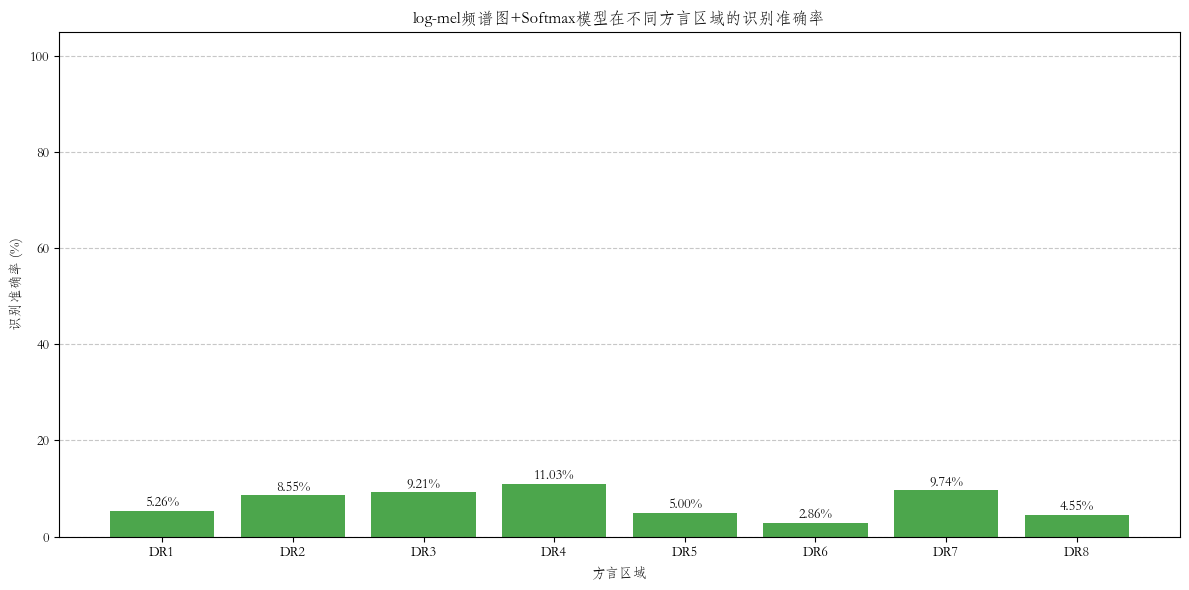

In [12]:
# 4. 分析方言区域对识别准确率的影响
def analyze_dialect_impact():
    """分析方言区域对模型性能的影响"""
    # 从数据中提取方言区域信息
    true_speaker_ids = [idx_to_speaker[idx] for idx in y_true]
    pred_speaker_ids = [idx_to_speaker[idx] for idx in y_pred]
    
    # 建立说话人ID到方言区域的映射
    dialect_dict = {}
    for item in test_data:
        dialect_dict[item['speaker_id']] = item['dialect_region']
    
    # 按方言区域分组计算准确率
    dialect_regions = sorted(set(dialect_dict.values()))
    dialect_accuracies = {}
    dialect_counts = {}
    
    for i, (true, pred) in enumerate(zip(true_speaker_ids, pred_speaker_ids)):
        if true not in dialect_dict:
            continue
            
        dialect = dialect_dict[true]
        
        if dialect not in dialect_counts:
            dialect_counts[dialect] = 0
            dialect_accuracies[dialect] = 0
            
        dialect_counts[dialect] += 1
        if true == pred:
            dialect_accuracies[dialect] += 1
    
    # 计算每个方言区域的准确率
    for dialect in dialect_accuracies:
        if dialect_counts[dialect] > 0:
            dialect_accuracies[dialect] = (dialect_accuracies[dialect] / dialect_counts[dialect]) * 100
    
    # 绘制方言区域准确率条形图
    plt.figure(figsize=(12, 6))
    regions = list(dialect_accuracies.keys())
    accuracies = [dialect_accuracies[r] for r in regions]
    
    bars = plt.bar(regions, accuracies, color='green', alpha=0.7)
    
    # 添加准确率标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.2f}%', ha='center', fontsize=10)
    
    plt.ylim(0, 105)
    plt.xlabel('方言区域')
    plt.ylabel('识别准确率 (%)')
    plt.title('log-mel频谱图+Softmax模型在不同方言区域的识别准确率')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

analyze_dialect_impact()

执行t-SNE降维...


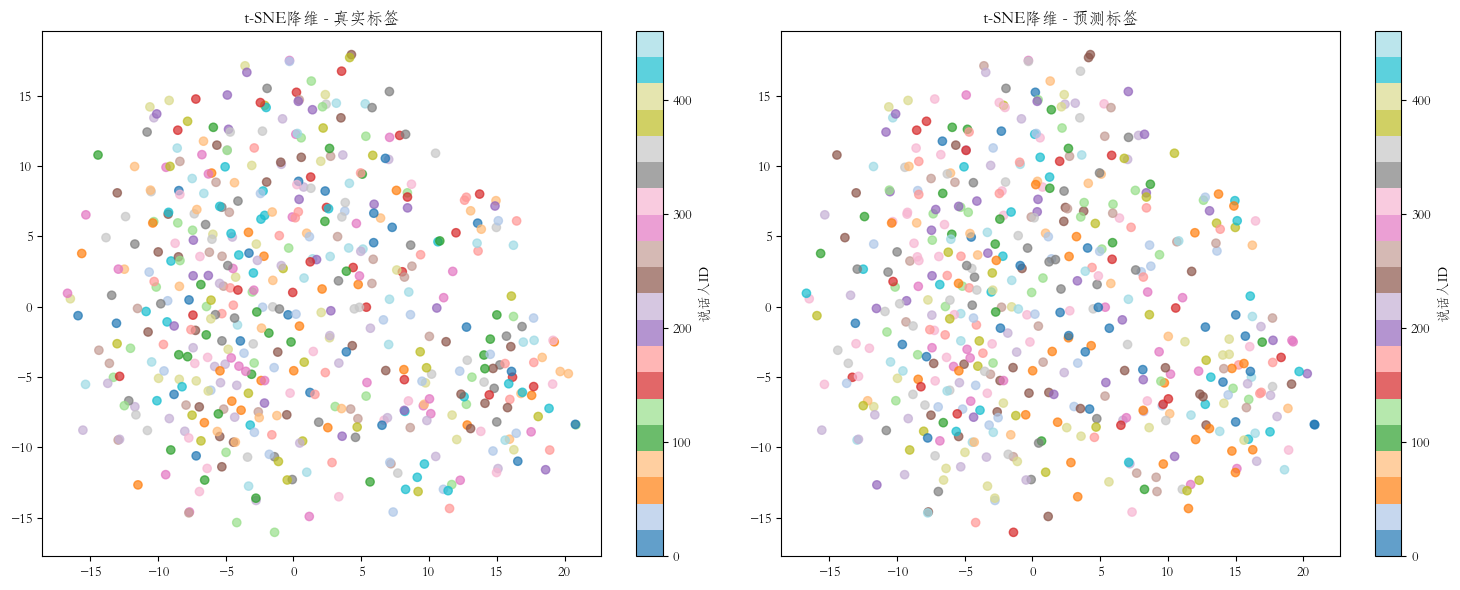

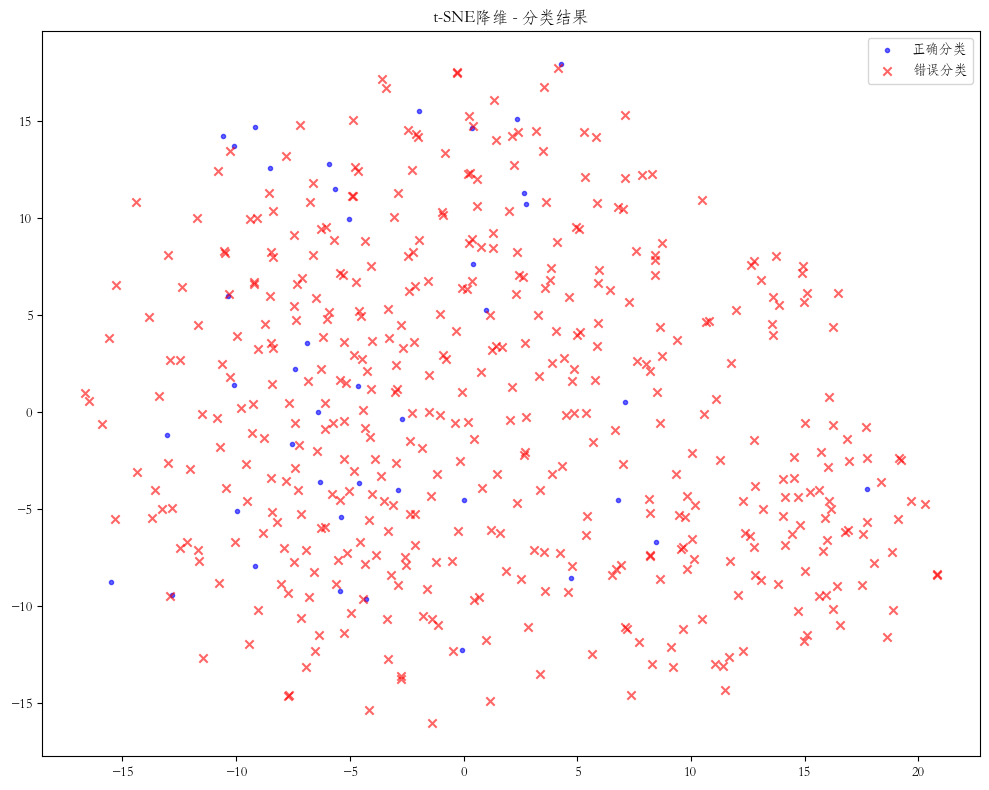

In [13]:
# 6. 可视化Softmax模型的决策边界
def visualize_decision_boundary():
    """使用降维技术可视化Softmax模型的决策"""
    # 使用t-SNE降维来可视化高维特征
    from sklearn.manifold import TSNE
    
    # 随机选择部分样本进行可视化（避免过多点导致图像混乱）
    if len(X_test) > 500:
        indices = np.random.choice(len(X_test), 500, replace=False)
        X_sample = X_test[indices]
        y_sample = y_test[indices]
        y_pred_sample = y_pred[indices]
    else:
        X_sample = X_test
        y_sample = y_test
        y_pred_sample = y_pred
    
    # 使用t-SNE降维
    print("执行t-SNE降维...")
    tsne = TSNE(n_components=2, random_state=42)
    X_tsne = tsne.fit_transform(X_sample)
    
    # 绘制降维后的特征点
    plt.figure(figsize=(15, 6))
    
    # 绘制真实标签
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='tab20', alpha=0.7)
    plt.title('t-SNE降维 - 真实标签')
    plt.colorbar(scatter, label='说话人ID')
    
    # 绘制预测标签
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred_sample, cmap='tab20', alpha=0.7)
    plt.title('t-SNE降维 - 预测标签')
    plt.colorbar(scatter, label='说话人ID')
    
    plt.tight_layout()
    plt.show()
    
    # 可视化正确和错误分类的样本
    correct = (y_sample == y_pred_sample)
    
    plt.figure(figsize=(10, 8))
    plt.scatter(X_tsne[correct, 0], X_tsne[correct, 1], c='blue', marker='.', alpha=0.6, label='正确分类')
    plt.scatter(X_tsne[~correct, 0], X_tsne[~correct, 1], c='red', marker='x', alpha=0.6, label='错误分类')
    plt.title('t-SNE降维 - 分类结果')
    plt.legend()
    plt.tight_layout()
    plt.show()


# 可视化决策边界
visualize_decision_boundary()

## 7. 结果讨论
讨论你的模型性能，尝试解释为什么某些模型比其他模型表现好，以及可能的改进方法。

## 8. 保存模型（可选）
如果需要，可以在这里添加代码保存你的模型。